# 🏦 Loan Default Prediction
## Supervised Machine Learning — Binary Classification Pipeline

**Dataset:** [Bank Loan Data — Kaggle](https://www.kaggle.com/datasets/udaymalviya/bank-loan-data) — 45,000 records, 14 columns

| Item | Detail |
|------|--------|
| **Goal** | Predict `loan_status` (0 = repaid, 1 = default) using pre-application customer attributes |
| **Dataset** | 45,000 records × 14 columns (Kaggle: udaymalviya/bank-loan-data) |
| **Models** | Logistic Regression (baseline) → Random Forest Classifier → XGBoost |
| **Imbalance handling** | `class_weight='balanced'` (Logistic Regression, Random Forest), `scale_pos_weight` (XGBoost) |
| **Stack** | Python, Pandas, Scikit-learn, XGBoost, Matplotlib, Seaborn, Tableau |

> This is **Model 2** of a 5-model series on the same dataset.


---
## 1. Setup & Import Libraries <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

sns.set(style='whitegrid')
%matplotlib inline

print('✅ Libraries loaded!')

✅ Libraries loaded!


---
## 2. Load & Understand Data <a id='2'></a>

In [2]:
df = pd.read_csv('loan_data.csv')

print(f'✅ Loaded successfully!')
print(f'Shape: {df.shape}')
df.head()

✅ Loaded successfully!
Shape: (45000, 14)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

Target distribution (loan_status):
loan_status
0    35000
1    10000
Name: count, dtype: int64

loan_status
0    0.7778
1    0.2222
Name: proportion, dtype: float64


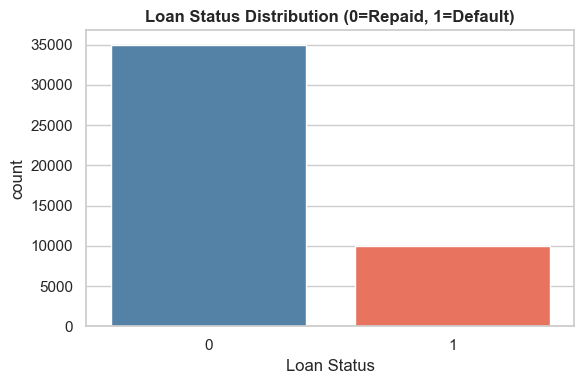

In [4]:
print('Target distribution (loan_status):')
print(df['loan_status'].value_counts())
print()
print(df['loan_status'].value_counts(normalize=True).round(4))

plt.figure(figsize=(6,4))
sns.countplot(x='loan_status', data=df, hue='loan_status', palette=['steelblue','tomato'], legend=False)
plt.title('Loan Status Distribution (0=Repaid, 1=Default)', fontweight='bold')
plt.xlabel('Loan Status')
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Data Cleaning & Preprocessing <a id='3'></a>

**Correct pipeline order:**
1. Drop leakage columns
2. Check and impute missing values
3. One-hot encode categorical columns — **done once here only**
4. `StandardScaler` applied **after** train-test split (Section 5)


In [5]:
# Step 1: Drop leakage columns
# loan_int_rate      -> priced based on risk after approval/default relationship is known
# loan_percent_income -> = loan_amnt / person_income
# loan_amnt          -> decision output, not a pre-application predictor for this model
df = df.drop(columns=['loan_int_rate', 'loan_percent_income', 'loan_amnt'])
print('After dropping leakage columns:', df.shape)
print('Remaining columns:', df.columns.tolist())

After dropping leakage columns: (45000, 11)
Remaining columns: ['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_intent', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file', 'loan_status']


In [6]:
# Step 2: Check missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)
print()

num_cols = df.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f'  Imputed: {col} -> median')

print('✅ Imputation complete')

Missing values per column:
person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_intent                       0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

✅ Imputation complete


In [7]:
# Step 3: One-hot encode categorical columns -- ONLY ONCE here
cat_cols = ['person_gender', 'person_education', 'person_home_ownership',
            'loan_intent', 'previous_loan_defaults_on_file']

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print('✅ Encoding complete')
print(f'Shape after encoding: {df.shape}')
print('Columns:', df.columns.tolist())

✅ Encoding complete
Shape after encoding: (45000, 20)
Columns: ['person_age', 'person_income', 'person_emp_exp', 'cb_person_cred_hist_length', 'credit_score', 'loan_status', 'person_gender_male', 'person_education_Bachelor', 'person_education_Doctorate', 'person_education_High School', 'person_education_Master', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'previous_loan_defaults_on_file_Yes']


In [8]:
# Verify: no object columns remain
obj_cols = df.select_dtypes(include='object').columns.tolist()
if obj_cols:
    print('⚠️ Object columns still present:', obj_cols)
else:
    print('✅ All columns numeric — ready for modeling')

✅ All columns numeric — ready for modeling


---
## 4. Feature Engineering <a id='4'></a>

In [9]:
# Income per year of employment -- financial stability proxy
df['Income_per_Emp_Year'] = df['person_income'] / (df['person_emp_exp'] + 1)

# Credit history density per year of age
df['Credit_History_per_Age'] = df['cb_person_cred_hist_length'] / (df['person_age'] + 1)

print('✅ Feature engineering complete')
print('New features: Income_per_Emp_Year, Credit_History_per_Age')

✅ Feature engineering complete
New features: Income_per_Emp_Year, Credit_History_per_Age


---
## 5. Train-Test Split & Scaling <a id='5'></a>

**Correct pipeline order:**
1. Define X and y
2. Stratified train-test split (80/20) **BEFORE** scaling — preserves class ratio
3. Fit `StandardScaler` on `X_train` **only** → transform `X_test` separately


In [10]:
X = df.drop(columns=['loan_status'])
y = df['loan_status']

print('Features:', X.columns.tolist())
print(f'\nX shape: {X.shape}')
print(f'y shape: {y.shape}')

Features: ['person_age', 'person_income', 'person_emp_exp', 'cb_person_cred_hist_length', 'credit_score', 'person_gender_male', 'person_education_Bachelor', 'person_education_Doctorate', 'person_education_High School', 'person_education_Master', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'previous_loan_defaults_on_file_Yes', 'Income_per_Emp_Year', 'Credit_History_per_Age']

X shape: (45000, 21)
y shape: (45000,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training set : {X_train.shape}')
print(f'Test set     : {X_test.shape}')

assert len(set(X_train.index) & set(X_test.index)) == 0
print('✅ No index overlap between train and test')

print(f'\nTrain class balance:\n{y_train.value_counts(normalize=True).round(4)}')
print(f'\nTest class balance:\n{y_test.value_counts(normalize=True).round(4)}')

Training set : (36000, 21)
Test set     : (9000, 21)
✅ No index overlap between train and test

Train class balance:
loan_status
0    0.7778
1    0.2222
Name: proportion, dtype: float64

Test class balance:
loan_status
0    0.7778
1    0.2222
Name: proportion, dtype: float64


In [12]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns, index=X_test.index)

print('✅ Scaling complete — scaler fit on training data only')
print(f'X_train mean ≈ 0: {X_train_scaled.mean().round(3).values[:4]}')
print(f'X_train std  ≈ 1: {X_train_scaled.std().round(3).values[:4]}')

✅ Scaling complete — scaler fit on training data only
X_train mean ≈ 0: [ 0. -0.  0.  0.]
X_train std  ≈ 1: [1. 1. 1. 1.]


---
## 6. Model Building & Evaluation <a id='6'></a>

In [13]:
def evaluate_model(y_true, y_pred, y_proba, model_name):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    auc  = roc_auc_score(y_true, y_proba)
    print(f'📊 {model_name}:')
    print(f'   Accuracy  : {acc:>8.4f}')
    print(f'   Precision : {prec:>8.4f}')
    print(f'   Recall    : {rec:>8.4f}')
    print(f'   F1-Score  : {f1:>8.4f}')
    print(f'   AUC-ROC   : {auc:>8.4f}')
    print('   Confusion Matrix:')
    print('   ', confusion_matrix(y_true, y_pred))
    print('-' * 45)
    return {'Model': model_name, 'Accuracy': round(acc,4), 'Precision': round(prec,4),
            'Recall': round(rec,4), 'F1': round(f1,4), 'AUC_ROC': round(auc,4)}

In [14]:
# Model 1: Logistic Regression (baseline) -- imbalance handled via class_weight
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr  = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
print('✅ Logistic Regression trained')

✅ Logistic Regression trained


In [15]:
# Model 2: Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
rf_clf.fit(X_train_scaled, y_train)
y_pred_rf  = rf_clf.predict(X_test_scaled)
y_proba_rf = rf_clf.predict_proba(X_test_scaled)[:, 1]
print('✅ Random Forest trained')

✅ Random Forest trained


In [16]:
# Model 3: XGBoost Classifier -- scale_pos_weight handles imbalance
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print(f'scale_pos_weight = {scale_pos_weight:.4f}')

xgb_clf = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, random_state=42,
    eval_metric='logloss', n_jobs=-1
)
xgb_clf.fit(X_train_scaled, y_train)
y_pred_xgb  = xgb_clf.predict(X_test_scaled)
y_proba_xgb = xgb_clf.predict_proba(X_test_scaled)[:, 1]
print('✅ XGBoost trained')

scale_pos_weight = 3.5000
✅ XGBoost trained


In [17]:
results = []
results.append(evaluate_model(y_test, y_pred_lr,  y_proba_lr,  'Logistic Regression'))
results.append(evaluate_model(y_test, y_pred_rf,  y_proba_rf,  'Random Forest'))
results.append(evaluate_model(y_test, y_pred_xgb, y_proba_xgb, 'XGBoost'))

results_df = pd.DataFrame(results).set_index('Model')
print('\nModel Comparison (Test Set):')
print(results_df.to_string())

📊 Logistic Regression:
   Accuracy  :   0.8038
   Precision :   0.5328
   Recall    :   0.9515
   F1-Score  :   0.6831
   AUC-ROC   :   0.9154
   Confusion Matrix:
    [[5331 1669]
 [  97 1903]]
---------------------------------------------
📊 Random Forest:
   Accuracy  :   0.8539
   Precision :   0.7060
   Recall    :   0.5870
   F1-Score  :   0.6410
   AUC-ROC   :   0.9240
   Confusion Matrix:
    [[6511  489]
 [ 826 1174]]
---------------------------------------------
📊 XGBoost:
   Accuracy  :   0.8466
   Precision :   0.6035
   Recall    :   0.9025
   F1-Score  :   0.7233
   AUC-ROC   :   0.9353
   Confusion Matrix:
    [[5814 1186]
 [ 195 1805]]
---------------------------------------------

Model Comparison (Test Set):
                     Accuracy  Precision  Recall      F1  AUC_ROC
Model                                                            
Logistic Regression    0.8038     0.5328  0.9515  0.6831   0.9154
Random Forest          0.8539     0.7060  0.5870  0.6410   0.9240
X

In [18]:
best_model_name = results_df['AUC_ROC'].idxmax()
print(f'🏆 Best model by AUC-ROC: {best_model_name}')

model_map = {'Logistic Regression': (log_reg, y_pred_lr, y_proba_lr),
             'Random Forest': (rf_clf, y_pred_rf, y_proba_rf),
             'XGBoost': (xgb_clf, y_pred_xgb, y_proba_xgb)}
best_model, y_pred_best, y_proba_best = model_map[best_model_name]

print('\nClassification Report (Best Model):')
print(classification_report(y_test, y_pred_best, target_names=['Repaid (0)', 'Default (1)']))

🏆 Best model by AUC-ROC: XGBoost

Classification Report (Best Model):
              precision    recall  f1-score   support

  Repaid (0)       0.97      0.83      0.89      7000
 Default (1)       0.60      0.90      0.72      2000

    accuracy                           0.85      9000
   macro avg       0.79      0.87      0.81      9000
weighted avg       0.89      0.85      0.86      9000



In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    X_train_scaled, y_train, cv=cv, scoring='roc_auc'
)
print(f'Cross-Validation AUC-ROC (Random Forest, 5-fold): {cv_scores.mean():.4f} ±{cv_scores.std():.4f}')

Cross-Validation AUC-ROC (Random Forest, 5-fold): 0.9251 ±0.0012


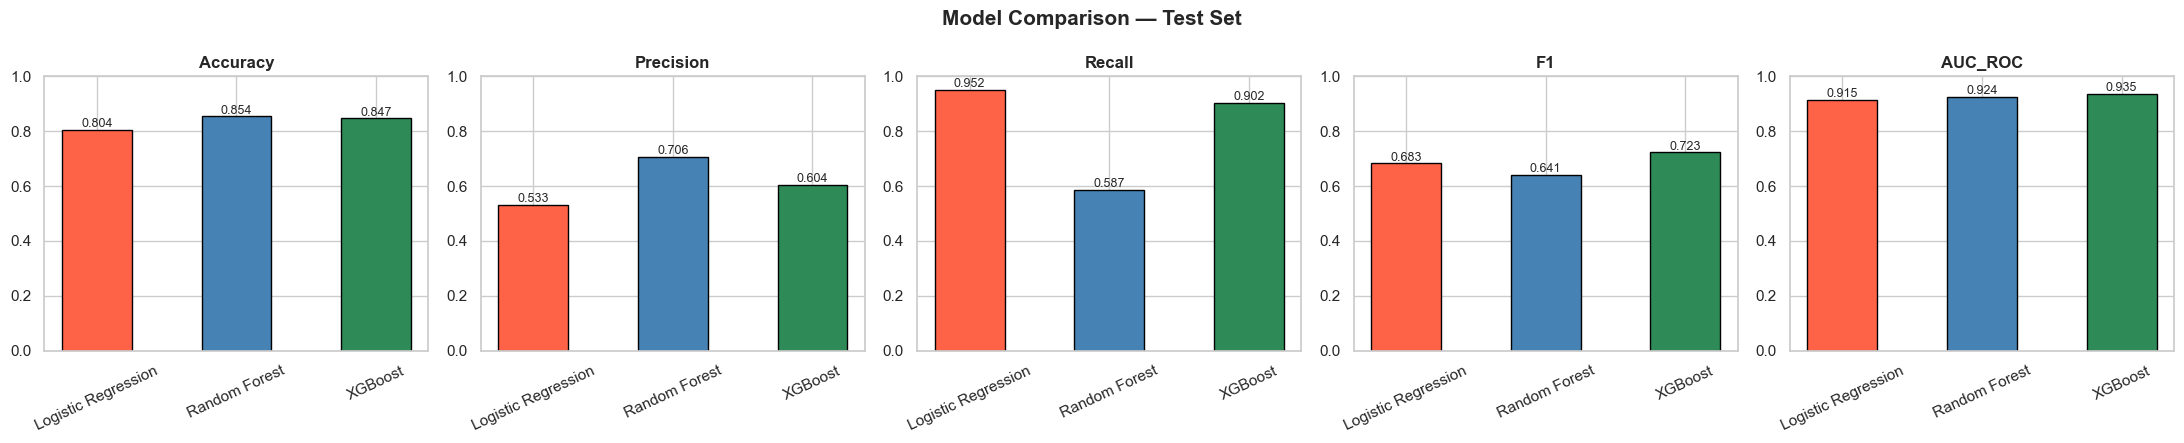

In [20]:
# Model comparison chart
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
colors = ['tomato', 'steelblue', 'seagreen']
for ax, metric in zip(axes, ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC_ROC']):
    vals = results_df[metric]
    bars = ax.bar(vals.index, vals.values, color=colors[:len(vals)], edgecolor='black', width=0.5)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1)
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{v:.3f}', ha='center', fontsize=9)
    ax.tick_params(axis='x', rotation=25)
plt.suptitle('Model Comparison — Test Set', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('model2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

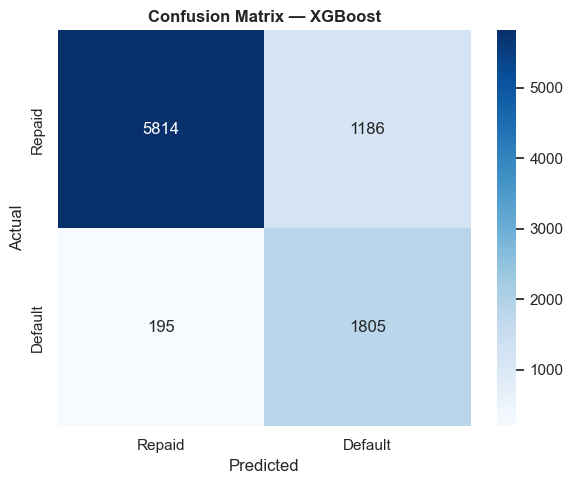

In [21]:
# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Repaid', 'Default'], yticklabels=['Repaid', 'Default'])
plt.title(f'Confusion Matrix — {best_model_name}', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

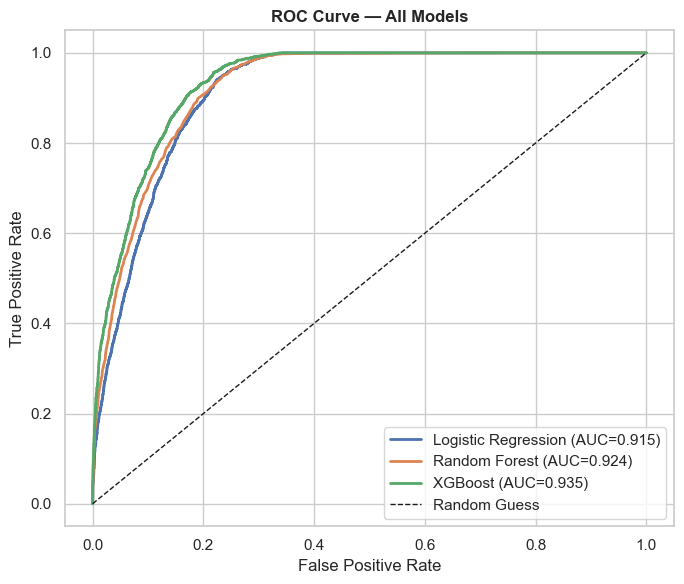

In [22]:
# ROC curve -- all models
plt.figure(figsize=(7, 6))
for name, (_, _, proba) in model_map.items():
    fpr_i, tpr_i, _ = roc_curve(y_test, proba)
    auc_i = roc_auc_score(y_test, proba)
    plt.plot(fpr_i, tpr_i, label=f'{name} (AUC={auc_i:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — All Models', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Feature Importance <a id='7'></a>

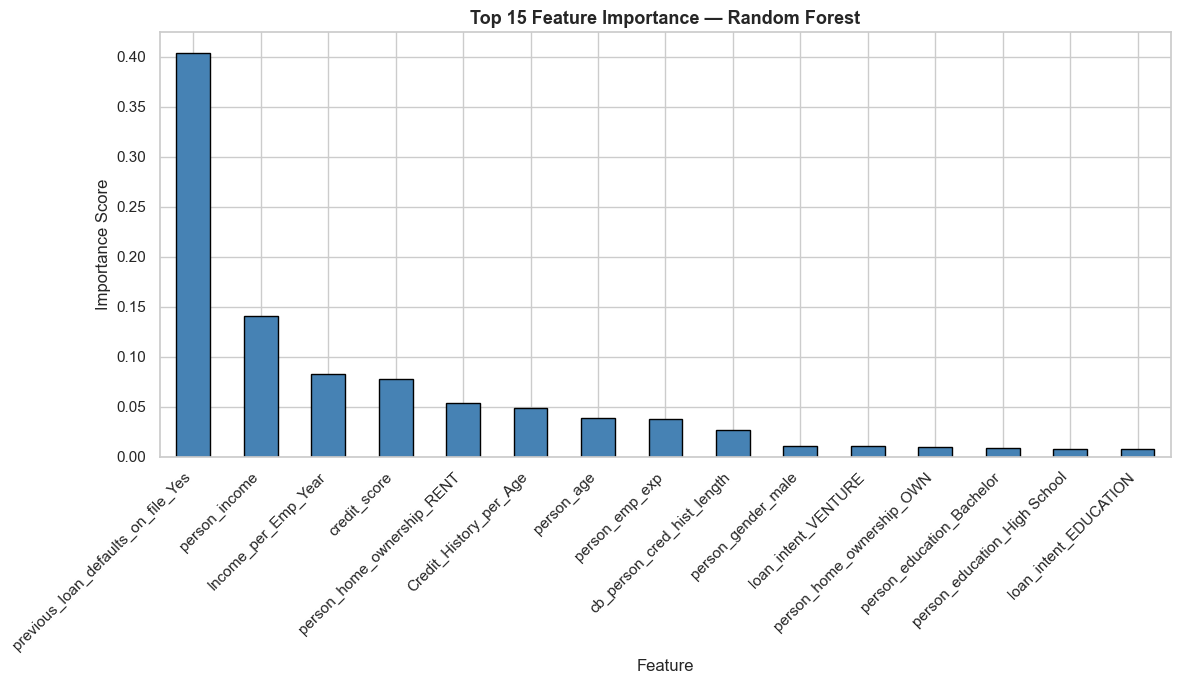

Feature Importance Ranking:
previous_loan_defaults_on_file_Yes    0.4041
person_income                         0.1411
Income_per_Emp_Year                   0.0830
credit_score                          0.0783
person_home_ownership_RENT            0.0540
Credit_History_per_Age                0.0493
person_age                            0.0390
person_emp_exp                        0.0376
cb_person_cred_hist_length            0.0270
person_gender_male                    0.0114


In [23]:
feature_importance = pd.Series(
    rf_clf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(12, 7))
feature_importance.head(15).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 15 Feature Importance — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance_default.png', dpi=150, bbox_inches='tight')
plt.show()

print('Feature Importance Ranking:')
print(feature_importance.head(10).round(4).to_string())

---
## 8. Tableau Export <a id='8'></a>

Exporting **only test-set rows** (out-of-sample predictions).


In [24]:
df_raw = pd.read_csv('loan_data.csv')
df_export = df_raw.loc[X_test.index].copy()
df_export['Predicted_Loan_Status'] = y_pred_best
df_export['Default_Probability']  = y_proba_best.round(4)
df_export['Prediction_Correct']   = (df_export['loan_status'] == df_export['Predicted_Loan_Status'])
df_export['Split']                = 'Test'
df_export.to_csv('loan_default_tableau_export.csv', index=False)
print(f'✅ Exported: loan_default_tableau_export.csv')
print(f'Rows exported (test only): {len(df_export):,}')

✅ Exported: loan_default_tableau_export.csv
Rows exported (test only): 9,000


In [25]:
importance_df = pd.DataFrame({
    'Feature': feature_importance.index,
    'Importance_Score': feature_importance.values
})
importance_df.to_csv('feature_importance_default.csv', index=False)
print('✅ Exported: feature_importance_default.csv')
print(importance_df.head(10).to_string(index=False))

✅ Exported: feature_importance_default.csv
                           Feature  Importance_Score
previous_loan_defaults_on_file_Yes          0.404124
                     person_income          0.141149
               Income_per_Emp_Year          0.083009
                      credit_score          0.078338
        person_home_ownership_RENT          0.054028
            Credit_History_per_Age          0.049258
                        person_age          0.038957
                    person_emp_exp          0.037639
        cb_person_cred_hist_length          0.027042
                person_gender_male          0.011383


In [26]:
results_df.reset_index().to_csv('model2_metrics_summary.csv', index=False)
print('✅ Exported: model2_metrics_summary.csv')
print(results_df.reset_index().to_string(index=False))

✅ Exported: model2_metrics_summary.csv
              Model  Accuracy  Precision  Recall     F1  AUC_ROC
Logistic Regression    0.8038     0.5328  0.9515 0.6831   0.9154
      Random Forest    0.8539     0.7060  0.5870 0.6410   0.9240
            XGBoost    0.8466     0.6035  0.9025 0.7233   0.9353


In [27]:
cm_df = pd.DataFrame(
    cm, index=['Actual_Repaid', 'Actual_Default'],
    columns=['Predicted_Repaid', 'Predicted_Default']
).reset_index().rename(columns={'index': 'Actual'})
cm_df.to_csv('confusion_matrix_export.csv', index=False)
print('✅ Exported: confusion_matrix_export.csv')

fpr, tpr, _ = roc_curve(y_test, y_proba_best)
roc_df = pd.DataFrame({'False_Positive_Rate': fpr, 'True_Positive_Rate': tpr})
roc_df.to_csv('roc_curve_export.csv', index=False)
print('✅ Exported: roc_curve_export.csv')

✅ Exported: confusion_matrix_export.csv
✅ Exported: roc_curve_export.csv


---
## 9. Conclusion & Recommendations <a id='9'></a>

### Pipeline Summary

| Step | Action | Correct Practice |
|------|--------|-------------------|
| Load | `pd.read_csv('loan_data.csv')` | ✅ |
| Preprocessing | Drop leakage columns (`loan_int_rate`, `loan_percent_income`, `loan_amnt`) | ✅ |
| Encoding | One-hot encode 5 categorical columns | ✅ Done **once** in Section 3 |
| Split | 80/20 stratified train-test | ✅ **Before** scaling, preserves class ratio |
| Scaling | `StandardScaler` | ✅ `fit` on train only |
| Imbalance | `class_weight='balanced'` / `scale_pos_weight` | ✅ No oversampling leakage |
| Feature Importance | From Random Forest only | ✅ Single consistent model |
| Export | Test rows only, with predicted probability | ✅ Out-of-sample only |

Fill in final metric numbers here once the notebook has been run end-to-end.
